# 1. Southeast Asia satellite evidence

This notebook builds the regional evidence used in the submission. It combines frozen public records from TROPOMI, EMIT, GHGSat, Sentinel-2, and Tanager. The records do not have the same coverage or reporting rules, so the comparison describes the public evidence rather than ranking sensor performance.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PACKAGE_ROOT = Path.cwd().resolve()
while not (PACKAGE_ROOT / "scripts").is_dir() and PACKAGE_ROOT != PACKAGE_ROOT.parent:
    PACKAGE_ROOT = PACKAGE_ROOT.parent

sys.path.insert(0, str(PACKAGE_ROOT / "scripts"))
import sea_analysis_pipeline as pipeline

FIG_DIR = PACKAGE_ROOT / "figures"
ANALYSIS_DIR = PACKAGE_ROOT / "data" / "sea_satellite_analysis" / "analysis"
AUDIT_DIR = ANALYSIS_DIR / "carbon_mapper_tanager_audit"


## Build one regional table

The first step puts the public records into the same columns for date, location, reported emission rate, and sector. All inputs are included under `data/sea_satellite_analysis/raw_extracts`.

In [2]:
summary = pipeline.rebuild_everything()
table = pipeline.read_csv_datetime(ANALYSIS_DIR / "sea_plume_table.csv")
print(summary)
display(table.groupby("sensor").agg(records=("plume_id", "count"), quantified=("emission_kg_hr", "count")))

{'plume_rows': 547, 'sensors': 5, 'overlap_events': 107, 'rate_comparable_pairs': 0, 'tanager_source_clusters': 93, 'distribution_rows': 5}


,records,quantified
sensor,,
EMIT (CarbonMapper),54,30
EMIT (NASA),8,1
GHGSat (open sample),70,70
TROPOMI (SRON),30,30
Tanager,385,229


## Where the public records exist

These views show the geographic coverage and dates represented in the combined table. Empty areas mean that no record appears in these public extracts. They do not prove that a satellite never observed the area.

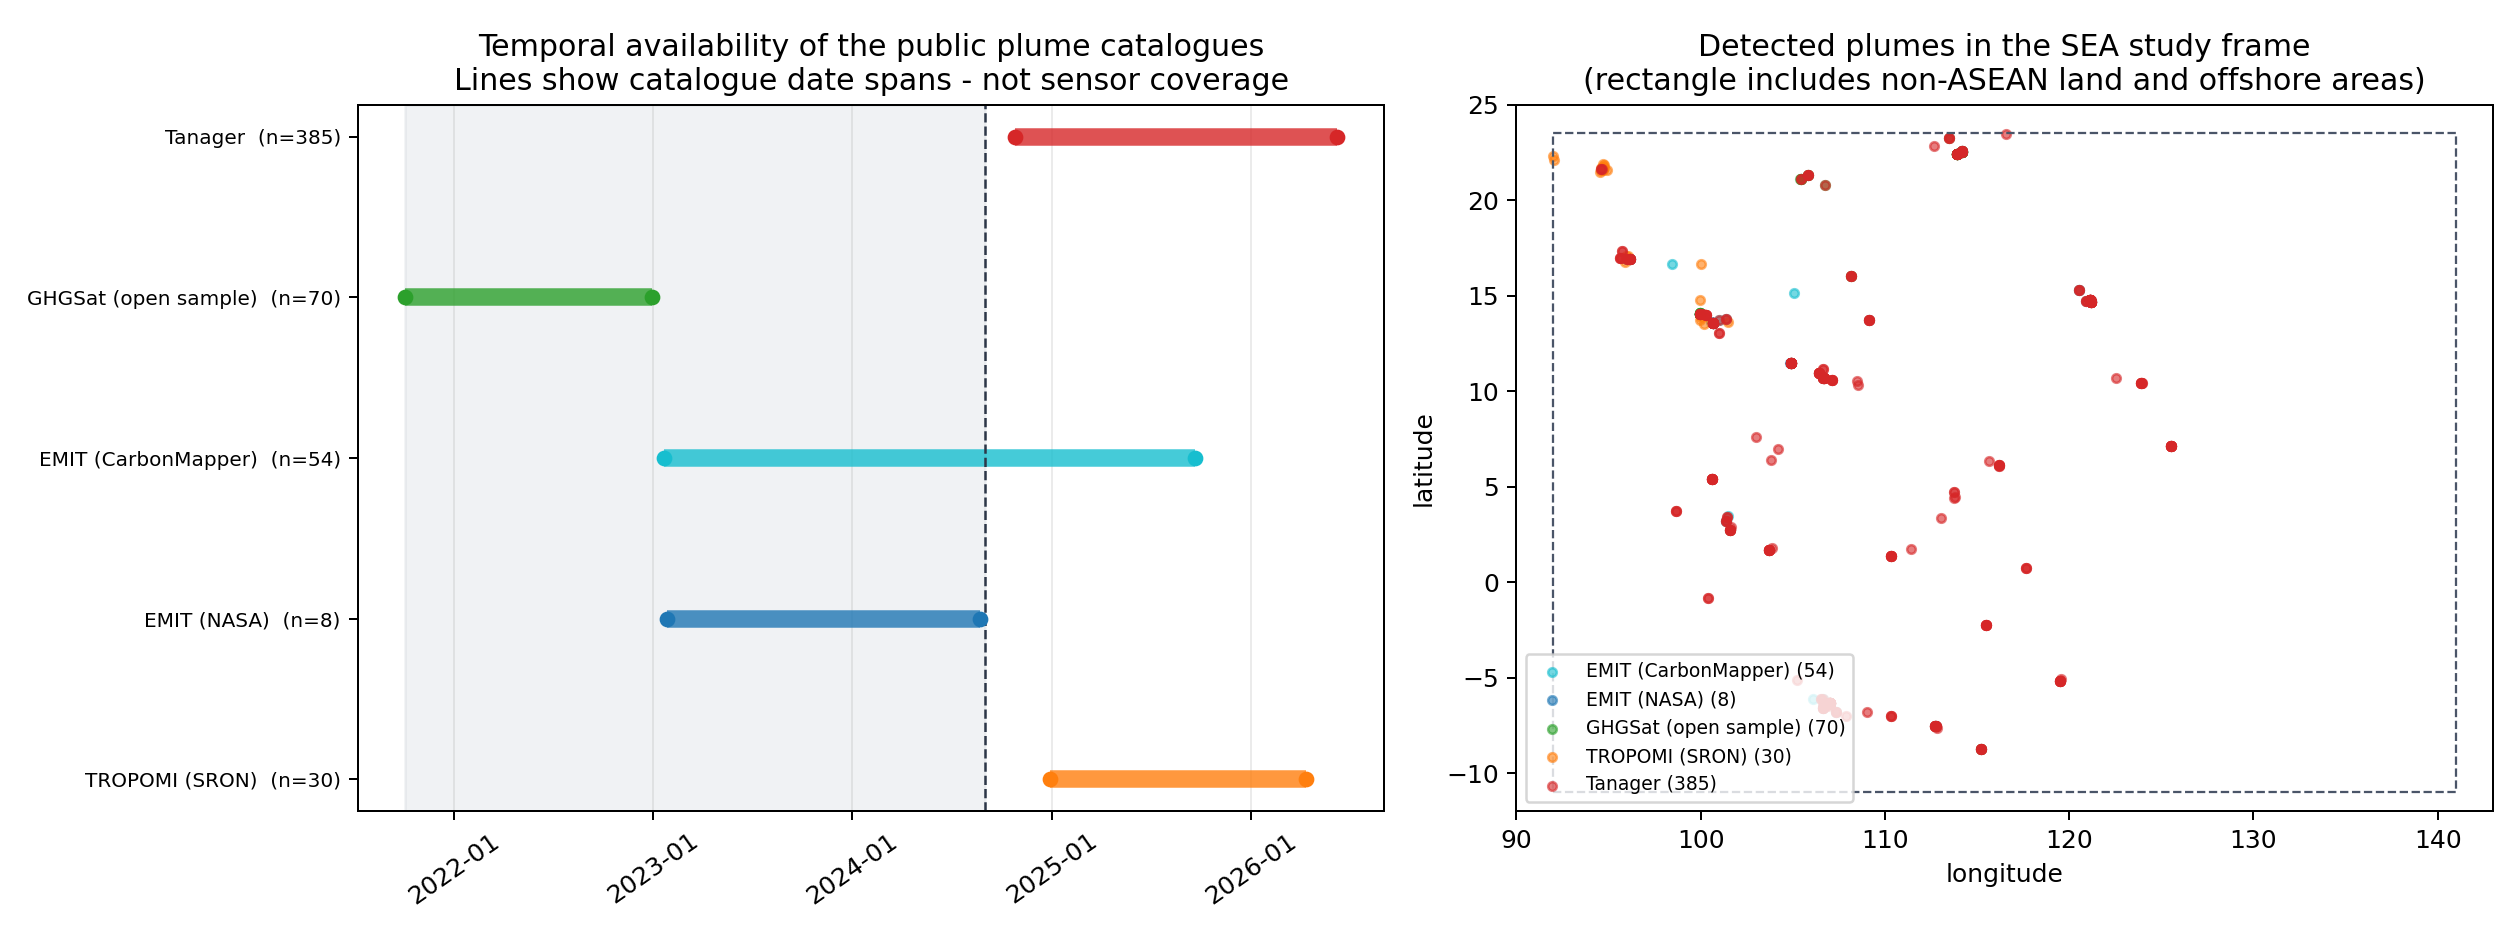

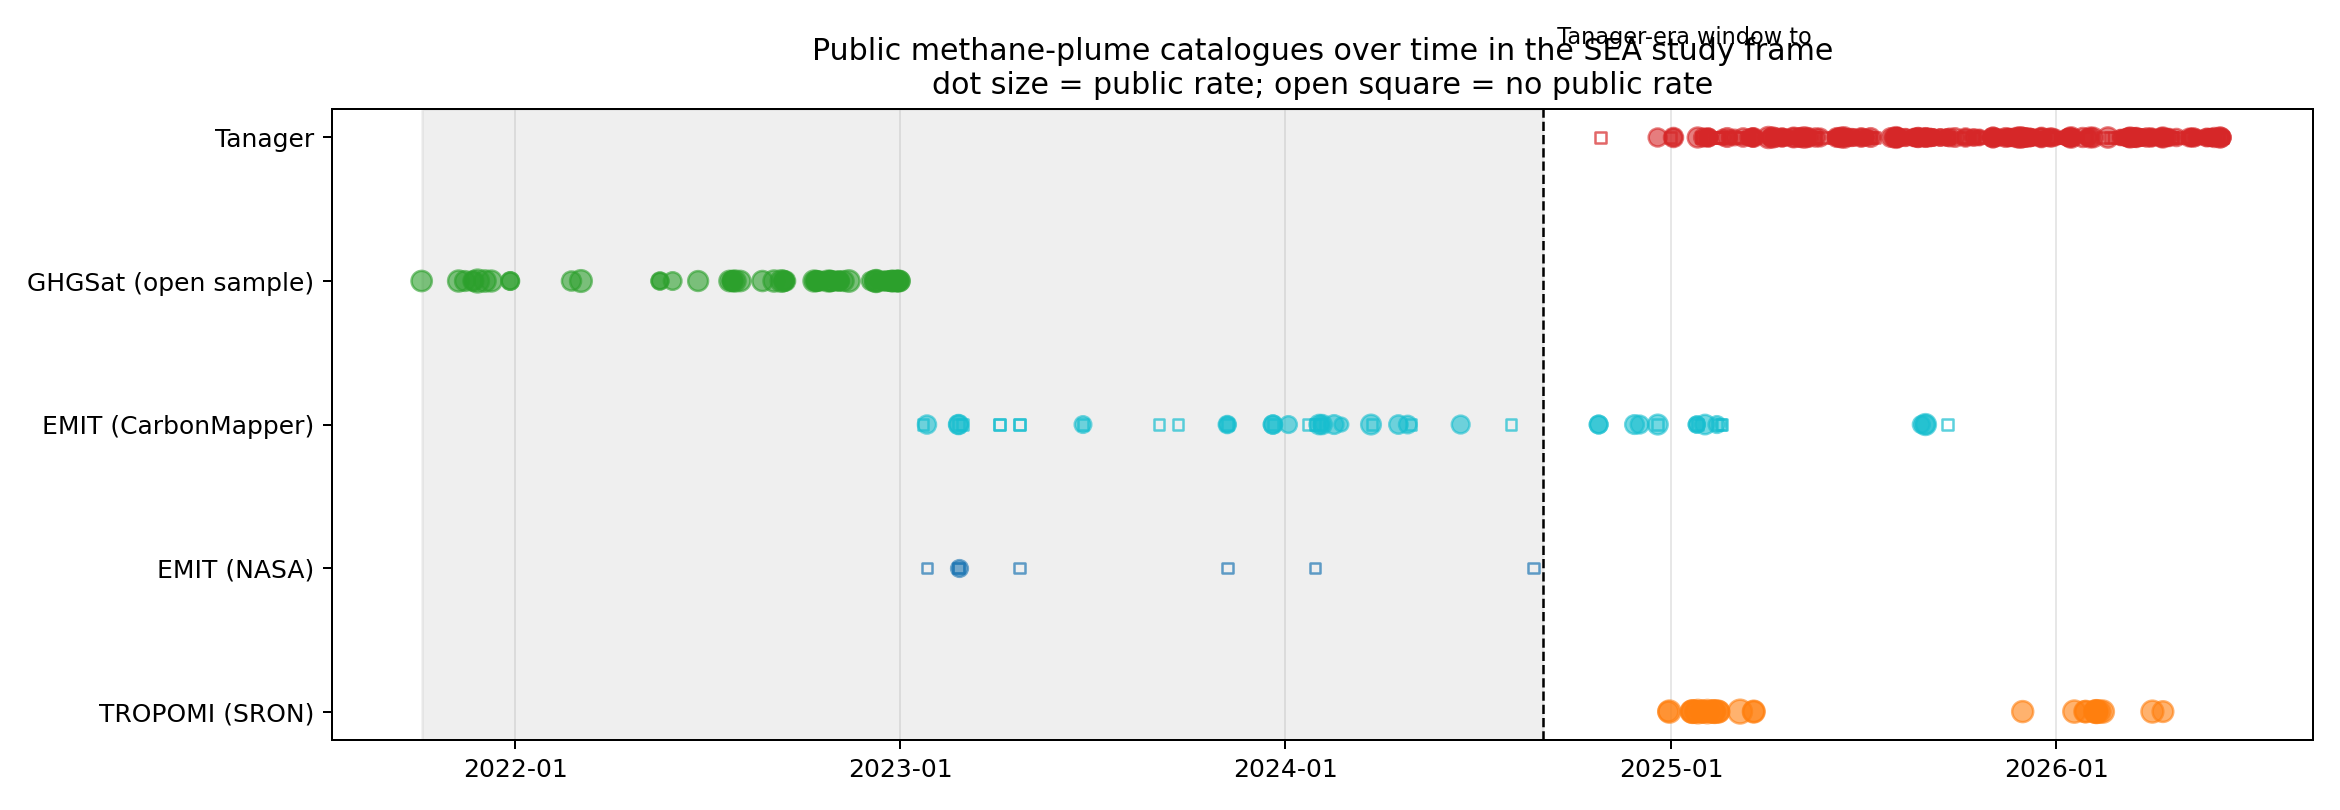

In [3]:
display(Image(filename=str(FIG_DIR / "01_coverage_map.png")))
display(Image(filename=str(FIG_DIR / "01_catalog_timeline.png")))

## Compare reported rates carefully

Each catalogue has its own reporting threshold and sampling pattern. The distribution plot therefore describes published values only. The overlap matrix counts nearby records, then separates same-day matches from revisits on different dates.

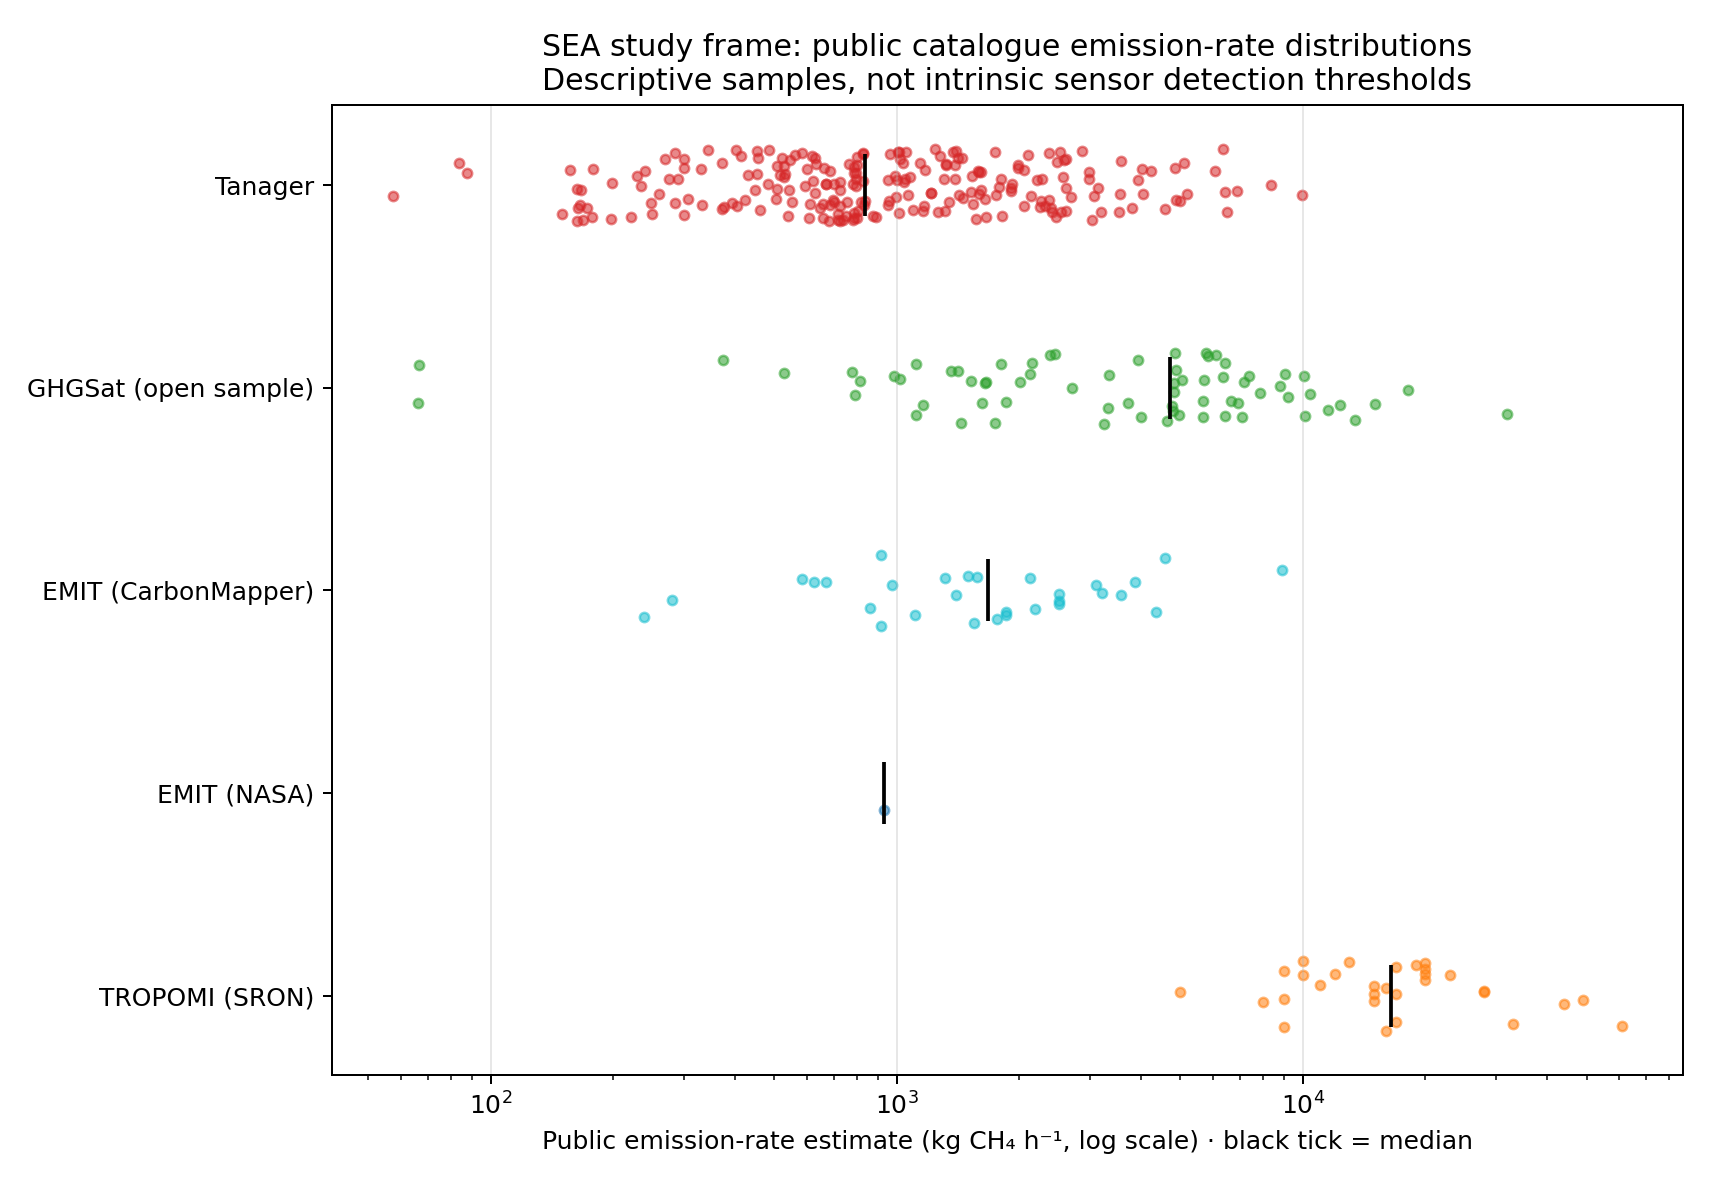

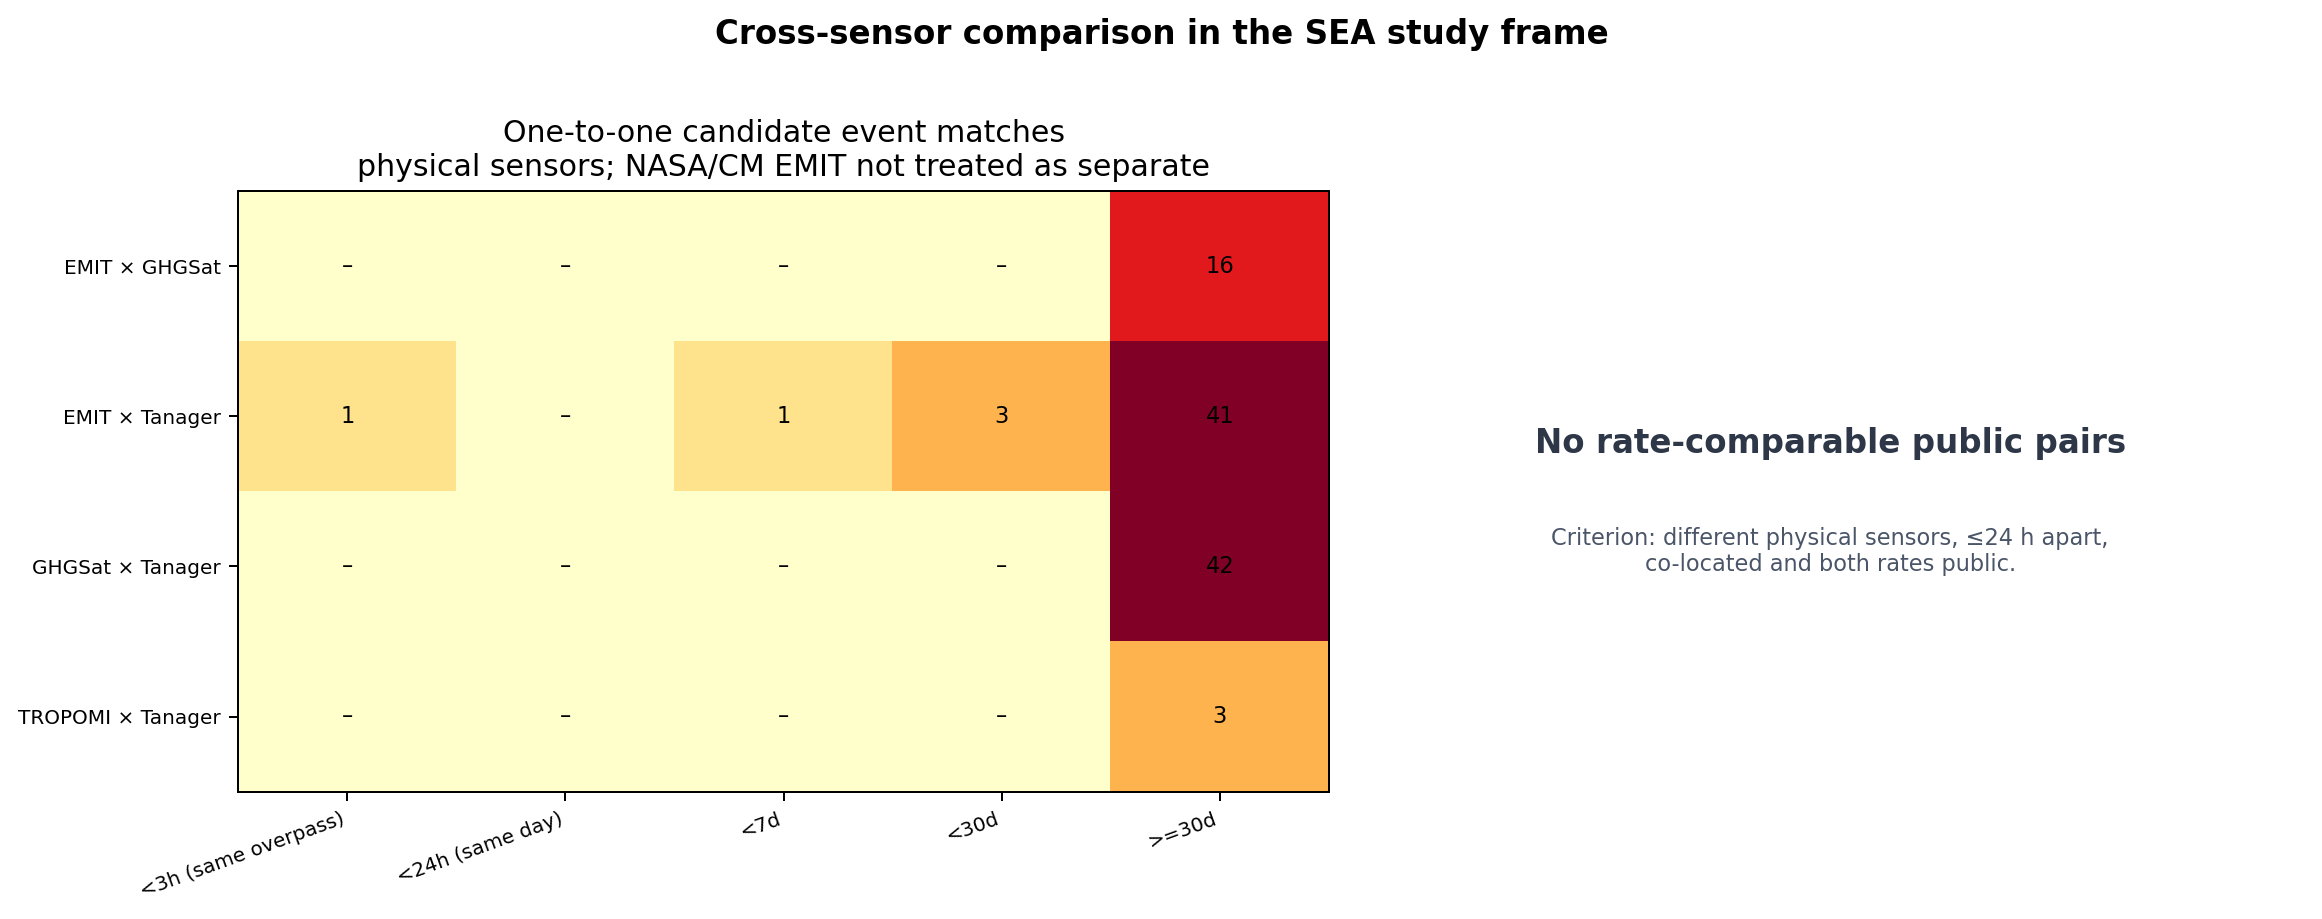

In [4]:
display(Image(filename=str(FIG_DIR / "01_rate_distributions.png")))
display(Image(filename=str(FIG_DIR / "01_overlap_matrix.png")))

## What the overlap check found

A nearby record from another sensor can support the case for a persistent source. It is not a direct validation when the observations were made on different days. The next maps show those source clusters and the lowest publicly reported rates by sensor.

,sensor_a,sensor_b,dt_bin,pairs
0,EMIT,GHGSat,>=30d,16
1,EMIT,Tanager,<30d,3
2,EMIT,Tanager,<3h (same overpass),1
3,EMIT,Tanager,<7d,1
4,EMIT,Tanager,>=30d,41
5,GHGSat,Tanager,>=30d,42
6,TROPOMI,Tanager,>=30d,3


,lat,lon,revisits,n_other_sensors,median_rate
0,11.483239,104.886881,20,1,1025.201578
1,10.416278,123.921015,6,0,1372.207201
2,3.372000,113.046783,1,0,3523.915576
3,-7.527659,112.711484,8,1,274.840337
4,6.108509,116.175829,5,0,585.188732
5,21.649477,94.623761,2,1,778.676164
6,-7.024887,110.358664,3,0,594.699753
7,21.339787,105.832961,1,1,1319.393387
8,13.582061,100.671351,14,1,696.114362
9,-6.422795,106.788441,2,0,1304.834620


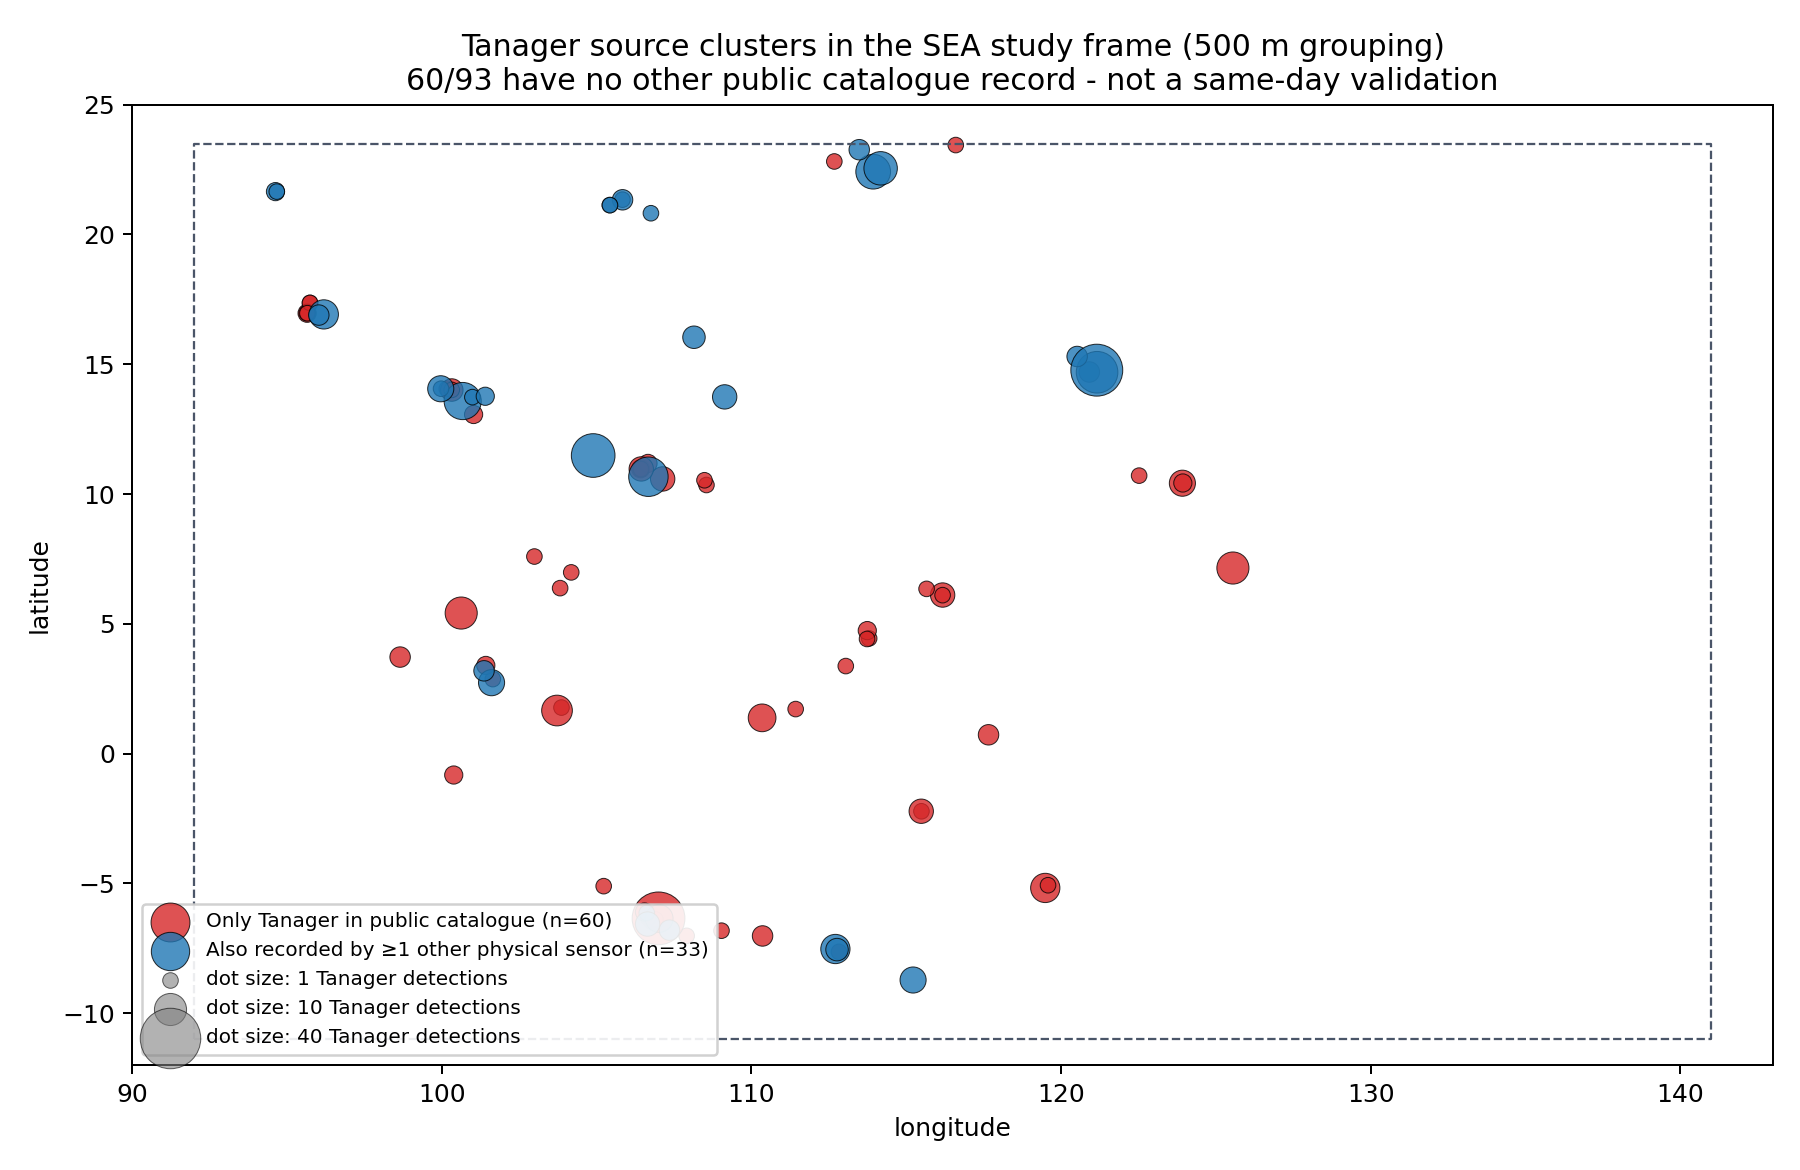

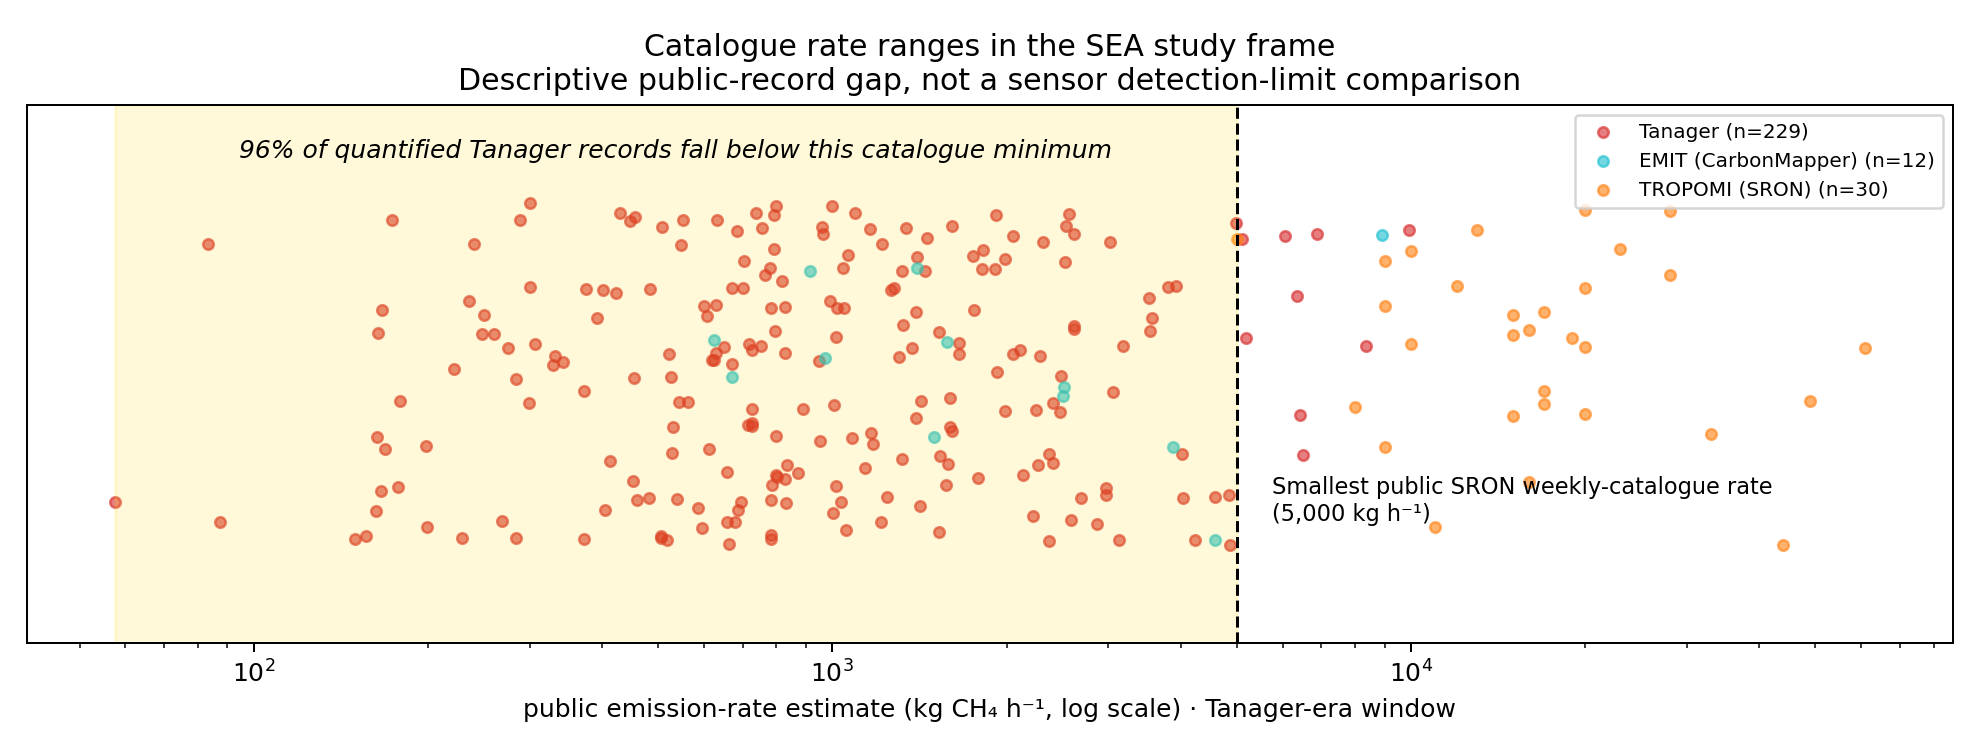

In [5]:
overlaps = pd.read_csv(ANALYSIS_DIR / "cross_sensor_overlaps.csv")
corroboration = pd.read_csv(ANALYSIS_DIR / "tanager_sources_corroboration.csv")
display(overlaps.groupby(["sensor_a", "sensor_b", "dt_bin"]).size().rename("pairs").reset_index())
display(corroboration.head(10))
display(Image(filename=str(FIG_DIR / "01_corroboration_map.png")))
display(Image(filename=str(FIG_DIR / "01_public_rate_floor.png")))

## Tanager records and the SEA use case

The sector chart shows what appears in the current Tanager public plume records. The interactive HTML map in `figures/01_sea_methane_map.html` lets the same records be inspected one by one.

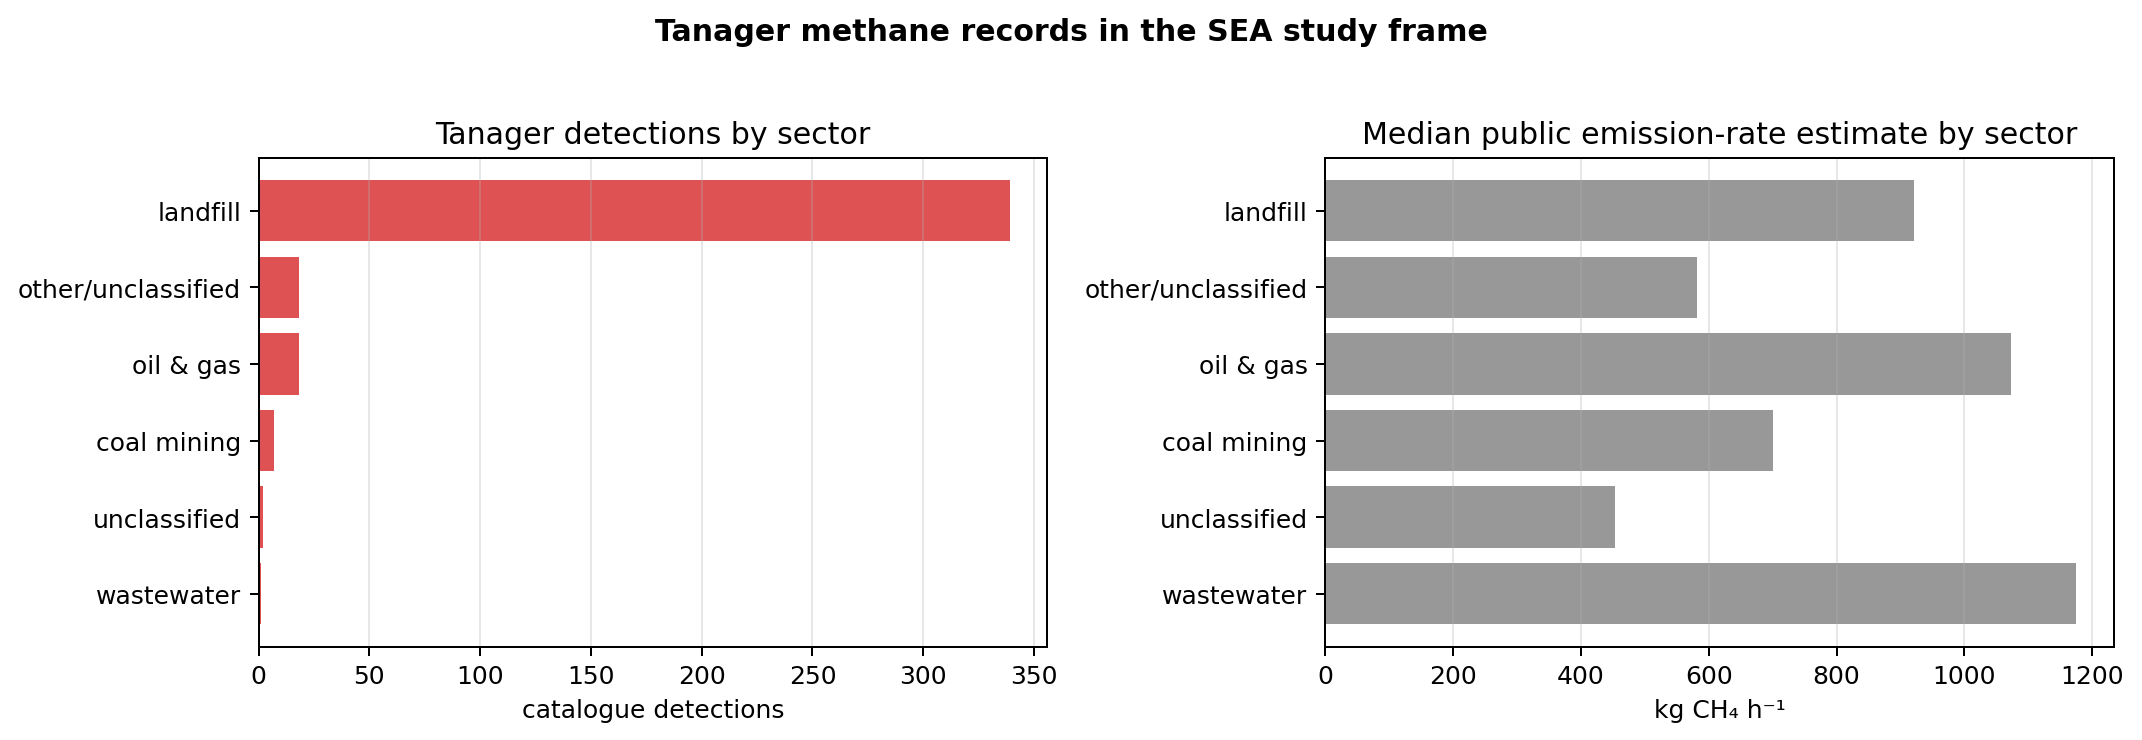

In [6]:
display(Image(filename=str(FIG_DIR / "01_tanager_sectors.png")))

## Carbon Mapper and Tanager gap audit

The detailed audit checks 385 public Tanager plume records against Carbon Mapper source records. It separates quantified records from hidden or unquantified ones, checks country and sector coverage, and identifies repeat-source candidates. This is the evidence behind the proposed 30-image portfolio.

,metric,value,unit,notes
0,audit_fetched_at_utc,2026-07-21T08:12:05.331749Z,timestamp,Live API audit date
1,fixed_cohort_plumes,385,plume observations,Existing SEA CSV
2,unique_tanager_scenes,237,scenes,Plume-bearing scenes only
3,carbon_mapper_sources_500m,93,sources,Native API grouping
4,publicly_quantified_plumes,229,plumes,Rate and uncertainty available
5,unquantified_or_hidden_plumes,156,plumes,No public emission_auto
6,unquantified_or_hidden_percent,40.5,percent,Fixed cohort
7,sources_with_no_public_rates,12,sources,Every cohort detection lacks rate
8,sources_with_mixed_rate_access,42,sources,"Some public, some hidden"
9,single_detection_date_sources,43,sources,Cohort only


,country,detections,sources_500m,unique_scenes,quantified,hidden_or_unquantified,median_public_rate_kg_hr,quantified_percent,asean_country
0,Indonesia,108,26,65,47,61,594.699753,43.5,True
1,Philippines,72,8,37,47,25,1043.926880,65.3,True
2,Vietnam,47,13,35,26,21,940.099883,55.3,True
3,Malaysia,46,11,33,28,18,779.199973,60.9,True
4,Thailand,32,9,20,21,11,1394.946429,65.6,True
5,Cambodia,20,1,10,10,10,1025.201578,50.0,True
6,Myanmar,20,9,10,13,7,599.718801,65.0,True
7,Brunei,0,0,0,0,0,NaN,NaN,True
8,Laos,0,0,0,0,0,NaN,NaN,True
9,Singapore,0,0,0,0,0,NaN,NaN,True


,sector,sector_label,detections,sources_500m,quantified,hidden_or_unquantified,median_public_rate_kg_hr,detection_share_percent,quantified_percent
0,6A,Solid waste / landfill,339,63,200,139,920.421040,88.1,59.0
1,1B2,Oil and gas,18,16,14,4,1072.281723,4.7,77.8
2,other,Other / unclassified,18,8,8,10,581.458459,4.7,44.4
3,1B1a,Coal mining,7,3,4,3,701.223530,1.8,57.1
4,NaN,Unclassified,2,2,2,0,452.897974,0.5,100.0
5,6B,Wastewater,1,1,1,0,1174.903368,0.3,100.0


,portfolio_component,image_count,evidence_from_audit,selection_rule,intended_learning
0,Missing-country first looks,8,"Brunei, Laos, Singapore, and Timor-Leste have ...","Two facility candidates per missing country, c...",Separate geographic tasking gaps from source a...
1,Quantification-recovery revisits,8,12 source clusters have no public rate and eac...,Revisit eight Tier-2 sources balanced across c...,Test whether a second acquisition converts a l...
2,Underrepresented sector and surface stress tests,6,88.1% of detections are landfill-coded; wastew...,Choose distinct actionable source classes and ...,Measure transferability and artifact behavior ...
3,Wet/dry seasonal pairs,4,The public positive catalogue cannot isolate m...,Select two high-priority sites and acquire one...,"Test cloud, moisture, surface, and source-seas..."
4,Quantified controls and cloud contingency,4,39 source clusters are quantified on every coh...,Reserve benchmark revisits and allow failed cl...,Anchor retrieval comparisons and protect the e...


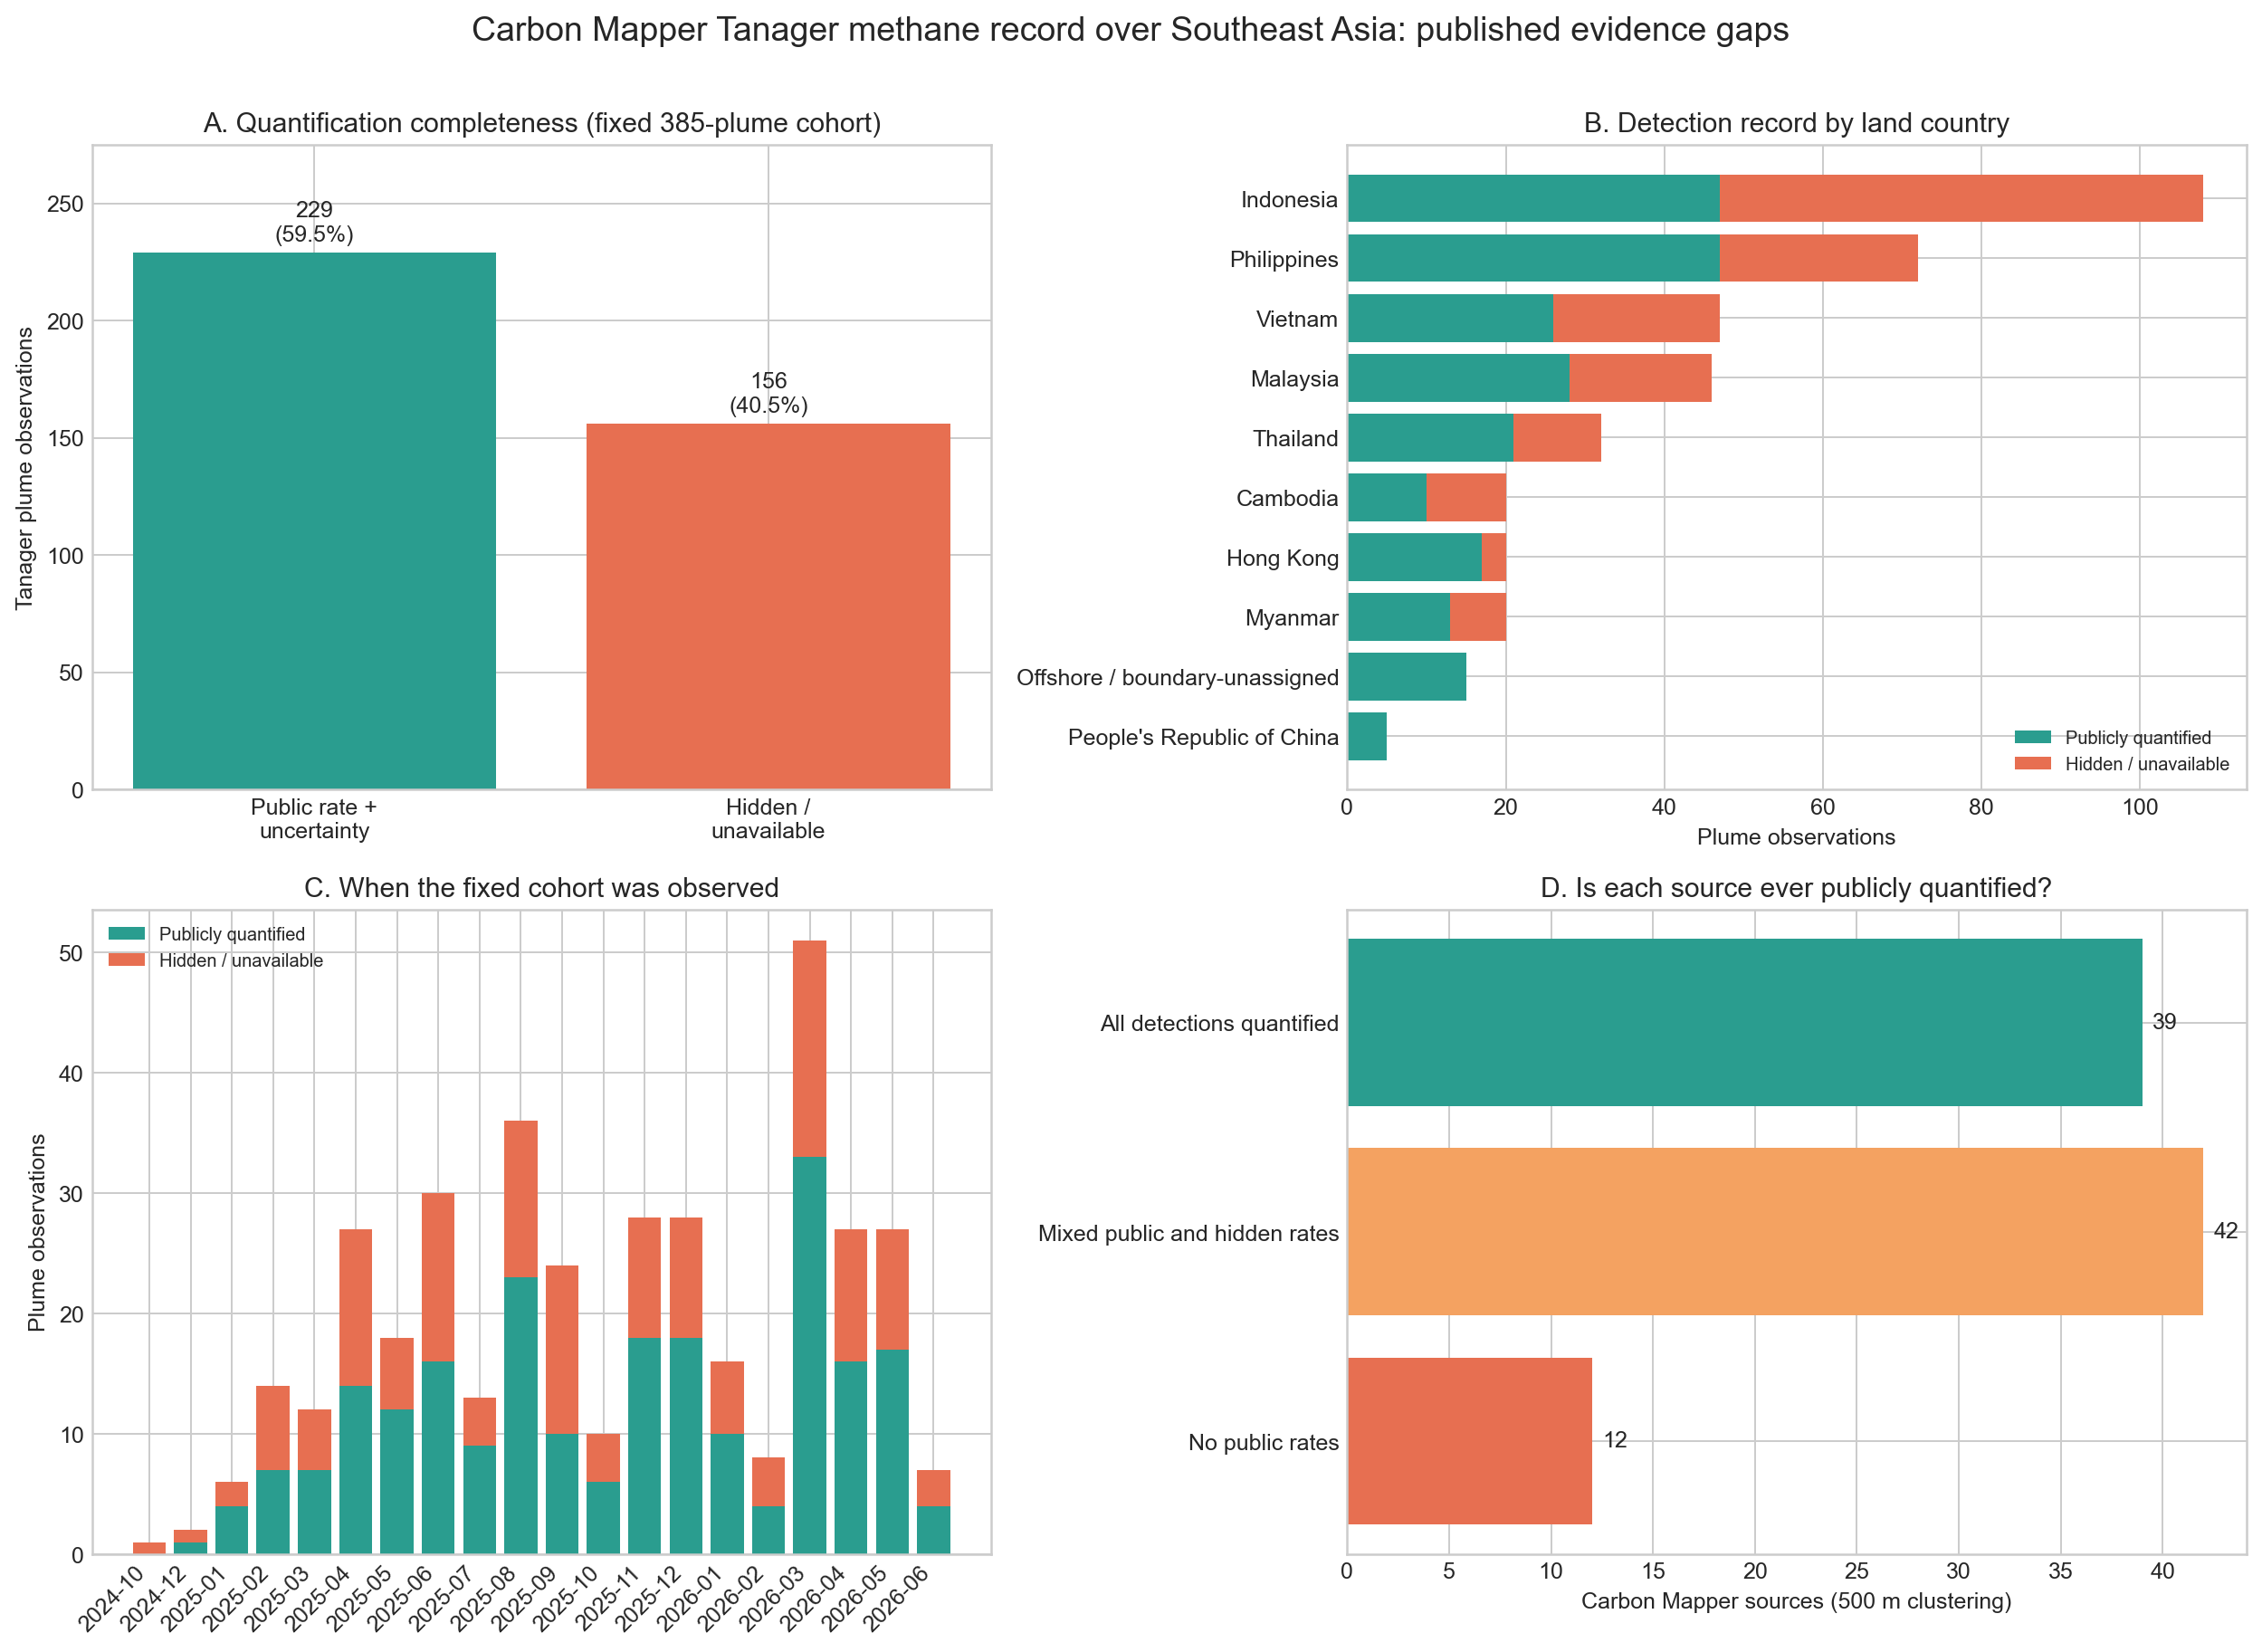

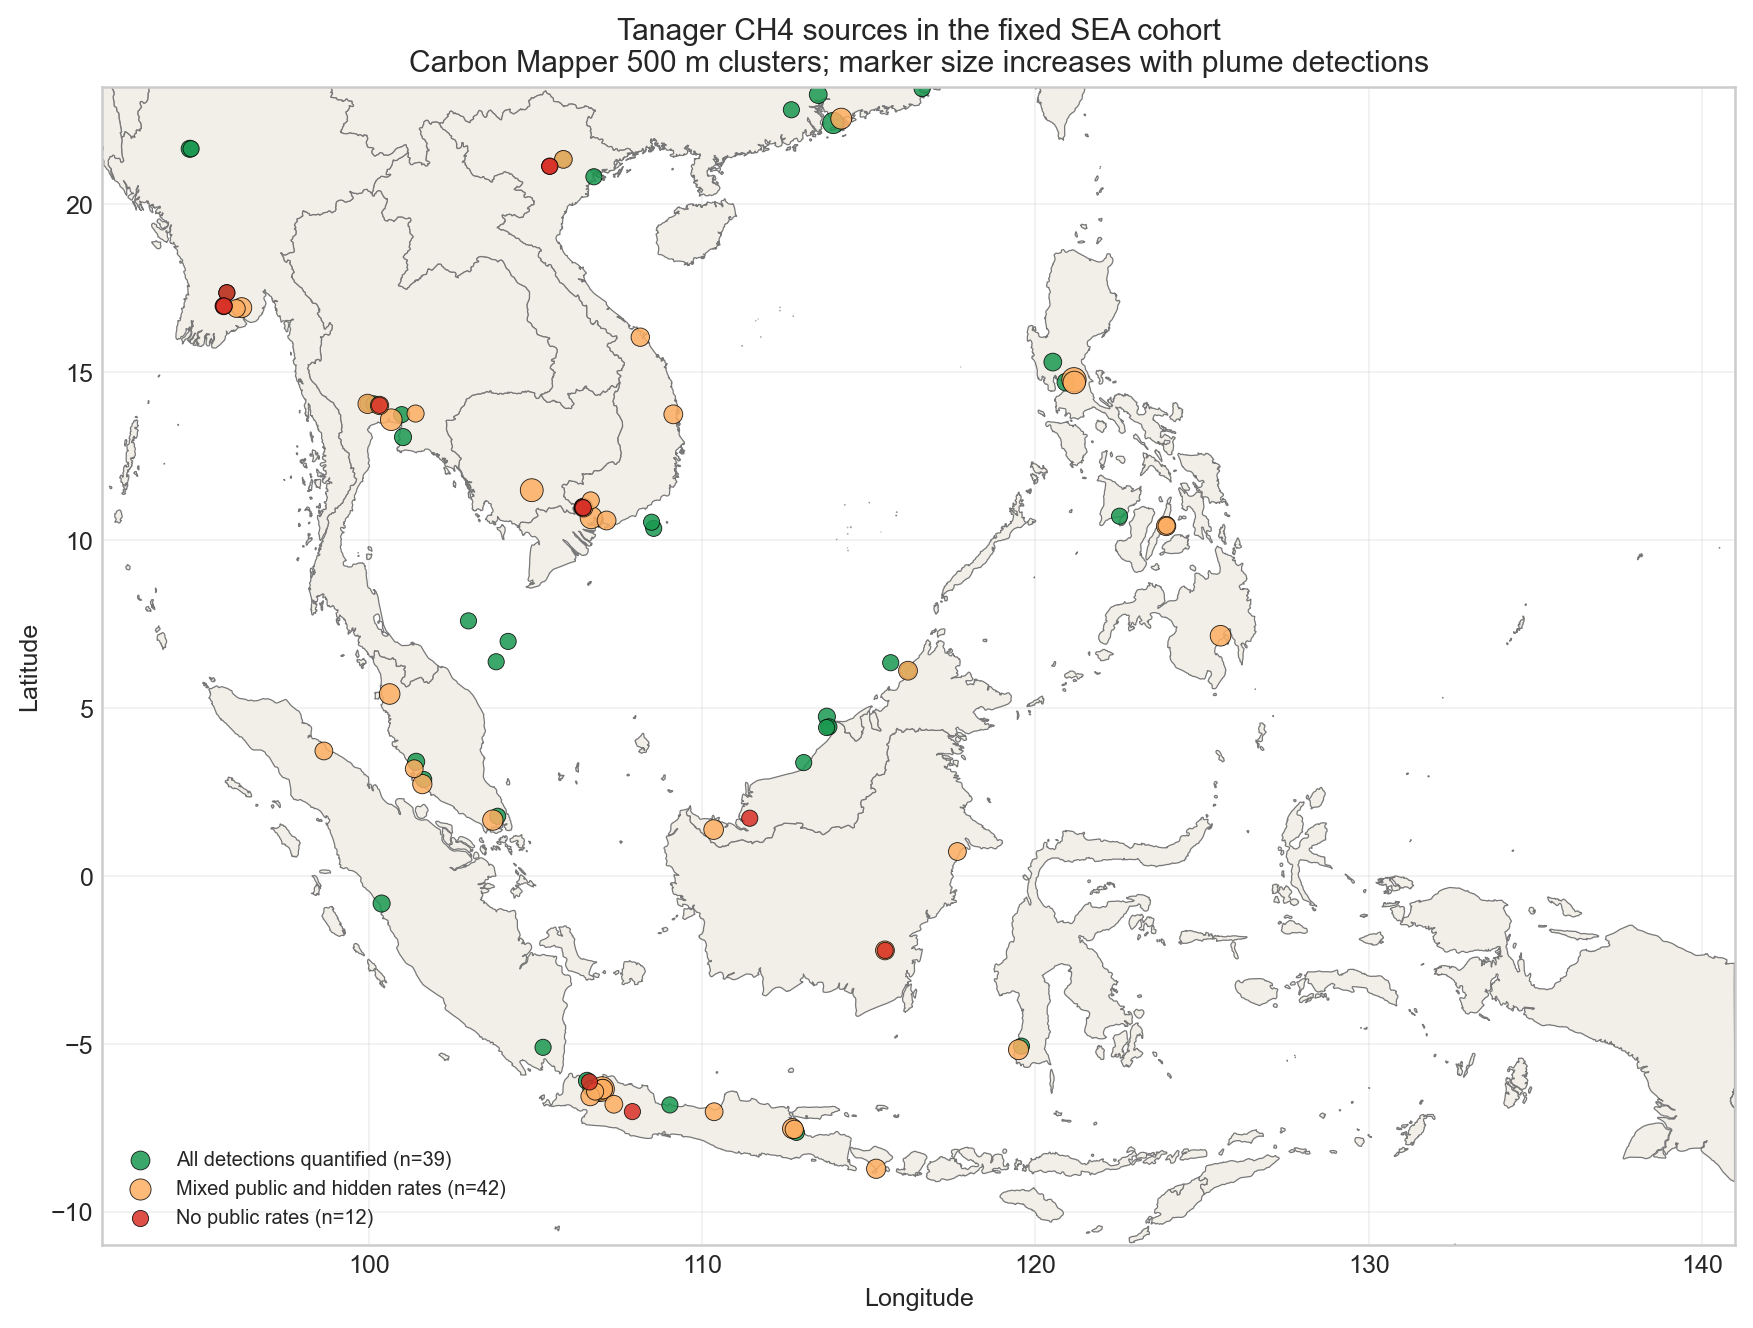

In [7]:
audit_summary = pd.read_csv(AUDIT_DIR / "audit_summary.csv")
country_coverage = pd.read_csv(AUDIT_DIR / "country_coverage.csv")
sector_coverage = pd.read_csv(AUDIT_DIR / "sector_coverage.csv")
portfolio = pd.read_csv(AUDIT_DIR / "provisional_30_image_design.csv")
display(audit_summary)
display(country_coverage)
display(sector_coverage)
display(portfolio)
display(Image(filename=str(FIG_DIR / "01_tanager_catalog_gap_audit.png")))
display(Image(filename=str(FIG_DIR / "01_tanager_source_gaps.png")))

## What this supports

The public catalogues leave a clear regional gap at facility scale. Tanager can help test repeat monitoring over palm-oil mill effluent ponds and other methane sources, but these records alone cannot establish a regional detection limit. The next notebooks test the retrieval on two open Tanager scenes where provider plume locations are available.